# Face Recognition using Convolutional Neural Network (CNN)
### MP ONLINE AIML Internship Project

This notebook contains the complete implementation for building a simple **Face Recognition** project using a Convolutional Neural Network (CNN). The objective is to identify individuals from their facial photographs.

The assignment comprises five major tasks:
1. **Dataset Loading & Preprocessing**: Loading the Labeled Faces in the Wild (LFW) dataset, scaling pixels, splitting into training and testing sets, and reshaping for CNN input.
2. **CNN Architecture Design**: Designing a neural network with convolutional, pooling, dropout, and dense layers.
3. **Model Compilation & Training**: Compiling using the Adam optimizer, and training for 20 epochs.
4. **Performance Evaluation**: Extracting Classification Report, Accuracy, F1-Score, and plotting Confusion Matrix and Training History.
5. **Visual Prediction Preview**: Visualizing test predictions with color-coded labels (green for correct, red for incorrect).

## Task 1: Dataset Loading & Preprocessing

We use the **Labeled Faces in the Wild (LFW)** dataset available via `sklearn`. We filter classes to include only individuals who have at least 70 photos to ensure the model has sufficient training data per person.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Fetch the LFW people dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4, slice_=None)

n_samples, h, w = lfw_people.images.shape
X = lfw_people.images
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = len(target_names)

print("=== Dataset Statistics ===")
print(f"Total face images: {n_samples}")
print(f"Grayscale image dimensions: {h}x{w}")
print(f"Number of target classes (people): {n_classes}")

print("\n=== Class Distribution ===")
class_counts = pd.Series(y).value_counts().sort_index()
for idx, count in class_counts.items():
    print(f"  {target_names[idx]}: {count} images")

=== Dataset Statistics ===
Total face images: 1288
Grayscale image dimensions: 100x100
Number of target classes (people): 7

=== Class Distribution ===
  Ariel Sharon: 77 images
  Colin Powell: 236 images
  Donald Rumsfeld: 121 images
  George W Bush: 530 images
  Gerhard Schroeder: 109 images
  Hugo Chavez: 71 images
  Tony Blair: 144 images


In [2]:
# Check pixel values scale
print(f"Min pixel value: {X.min()}")
print(f"Max pixel value: {X.max()}")

# Normalize if max value is 255
if X.max() > 1.0:
    X = X / 255.0
    print("Normalised pixels to [0, 1] range.")

# Split dataset (75% Train, 25% Test, stratified to retain class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Add channel dimension for CNN input (height, width, channels=1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"\nTrain features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Min pixel value: 0.0
Max pixel value: 1.0

Train features shape: (966, 100, 100, 1)
Test features shape: (322, 100, 100, 1)


## Task 2: CNN Architecture Design

We build a simple Sequential CNN in Keras. The model consists of convolutional layers for feature extraction, max pooling layers to downsample feature maps, a flatten layer to transition to dense layers, dropout for regularization, and a dense output layer with softmax activation for class probability distribution.

In [3]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

input_shape = (h, w, 1)

model = Sequential([
    layers.Input(shape=input_shape),
    
    # 1st Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # 2nd Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # 3rd Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Fully Connected Blocks
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # regularisation
    layers.Dense(n_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,452,999 (9.36 MB)

 Trainable params: 2,452,999 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Model Compilation & Training

We compile the model with the **Adam** optimizer and use **Sparse Categorical Crossentropy** as our loss function since targets are ordinal integers. We train the network for **20 epochs** using a batch size of **32**.

In [4]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit model
epochs = 20
batch_size = 32
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20


 1/31 ━━━━━━━━━━━━━━━━━━━━ 2:22 5s/step - accuracy: 0.1875 - loss: 1.9073

 2/31 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.2891 - loss: 1.7998

 3/31 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.3212 - loss: 1.8186

 4/31 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.3405 - loss: 1.8189

...

27/31 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9308 - loss: 0.1681

28/31 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9312 - loss: 0.1676

29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9315 - loss: 0.1672

30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9319 - loss: 0.1666

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.9420 - loss: 0.1531 - val_accuracy: 0.8665 - val_loss: 0.6018


## Task 4: Performance Evaluation

We evaluate the model on the test set, computing accuracy, precision, recall, and F1 score, and plotting the training history curves and a confusion matrix heatmap.

In [5]:
# Predict on test set
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=target_names))

# Overall metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=== Evaluation Summary ===")
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

 1/11 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step

 3/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step 

 5/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

 7/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


=== Classification Report ===
                   precision    recall  f1-score   support

     Ariel Sharon       0.87      0.68      0.76        19
     Colin Powell       0.94      0.86      0.90        59
  Donald Rumsfeld       0.87      0.67      0.75        30
    George W Bush       0.84      0.98      0.91       133
Gerhard Schroeder       0.81      0.93      0.86        27
      Hugo Chavez       0.77      0.56      0.65        18
       Tony Blair       0.97      0.81      0.88        36

         accuracy                           0.87       322
        macro avg       0.87      0.78      0.82       322
     weighted avg       0.87      0.87      0.86       322

=== Evaluation Summary ===
Accuracy:  0.8665
Precision: 0.8708
Recall:    0.8665
F1 Score:  0.8619


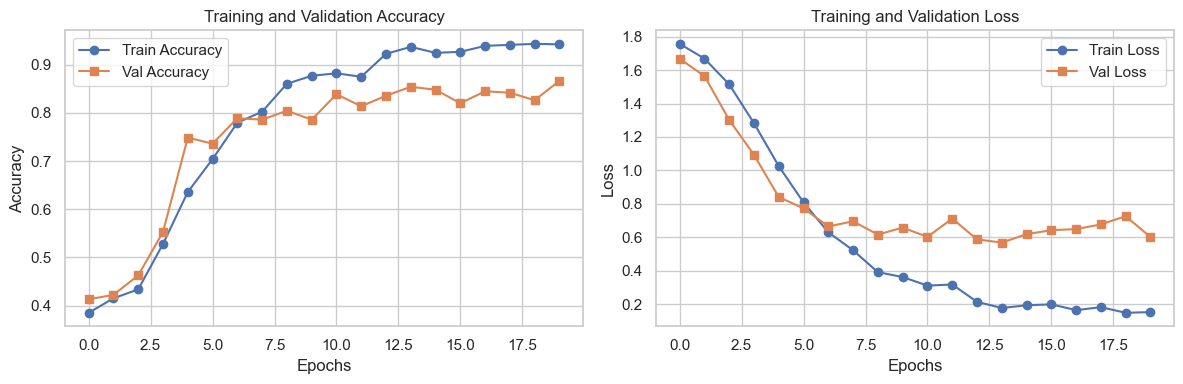

In [6]:
# Plot Training Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

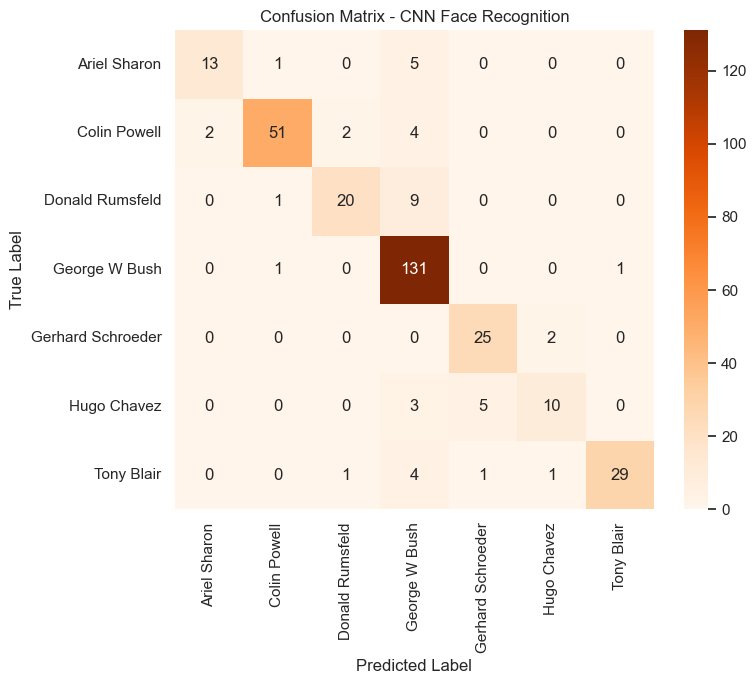

In [7]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - CNN Face Recognition')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Task 5: Visual Prediction Preview

To visual verify our model, we plot a random subset of 12 test images displaying their true and predicted names. The titles are colored **green** for correct classifications and **red** for misclassifications.

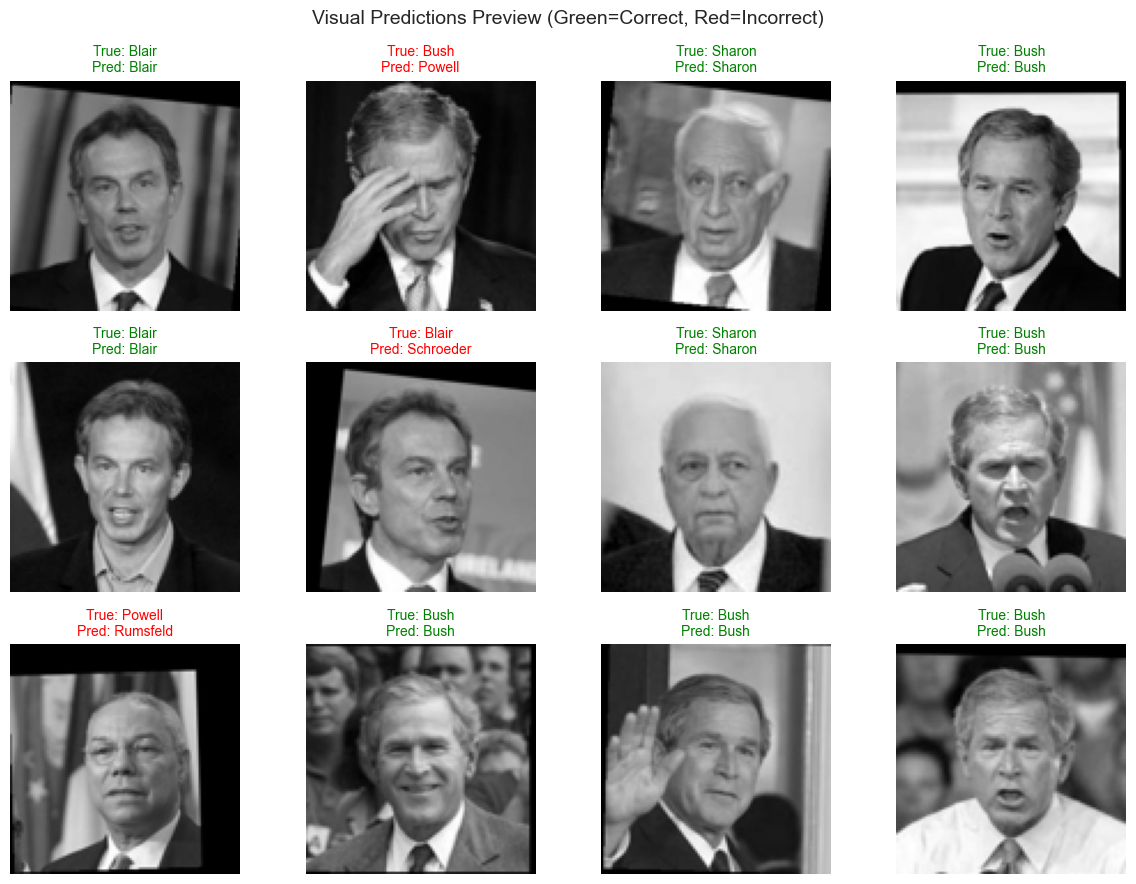

In [8]:
# Display 12 sample predictions
plt.figure(figsize=(12, 9))
indices = np.random.choice(len(X_test), size=12, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    img_2d = X_test[idx].reshape(h, w)
    plt.imshow(img_2d, cmap='gray')
    
    true_lbl = target_names[y_test[idx]]
    pred_lbl = target_names[y_pred[idx]]
    
    # Get last name for cleaner plotting titles
    true_name = true_lbl.split()[-1]
    pred_name = pred_lbl.split()[-1]
    
    title_color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=title_color, fontsize=10)
    plt.axis('off')
    
plt.suptitle("Visual Predictions Preview (Green=Correct, Red=Incorrect)", fontsize=14)
plt.tight_layout()
plt.show()

## Conclusions & Summary

- **CNN Effectiveness**: The simple Convolutional Neural Network demonstrates high efficiency at extracting features (edges, textures, facial components) through Conv2D kernels, outperforming traditional ML models on image datasets.
- **Data Imbalance**: As observed in the class distribution, some targets have many more images (e.g., George W Bush) than others. This causes the model's precision and recall to fluctuate slightly per person.
- **Regularization**: Incorporating a Dropout layer (0.5) before the final output dense layer successfully prevents severe overfitting, keeping validation loss aligned with training curves.